In [1]:
if "moved_up_dir" not in globals():
    # Code that should run once
    %cd ..
    moved_up_dir = True
else:
    print("Skipping — already executed this session.")

/home/woodbkb2/git/nepo-music


In [2]:
import json
import sys
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv

from apis import spotify as sp
from base_model import features_calculator as fc
from tqdm import tqdm

load_dotenv()

True

In [3]:

DATA_DIR = Path('./data')
ARTIST_FULL_DATA = DATA_DIR / "artist_full_data" / "old1"
OUTPUT_FILE = DATA_DIR / "artist_base_features.csv" 
NUM_YEARS = 5

EXCLUDE_LIST = {'[unknown]'}
    

In [7]:
failures = 0
processed = 0
raw_conversions = []

files = [f for f in ARTIST_FULL_DATA.iterdir() if f.suffix == ".jsonl"]

outer_bar = tqdm(files, desc="Files", unit="file", position=0)

for i, file in enumerate(outer_bar):
    try:
        with file.open() as f:
            # new inner bar, always in the same row (position=1)
            inner_bar = tqdm(
                f,
                desc=f"{file.name}",
                unit="row",
                leave=False,
                position=1,
            )

            for raw_artist_work_data in inner_bar:
                try:
                    processed += 1
                    artist_work_data = json.loads(raw_artist_work_data)

                    if artist_work_data["artist_name"] in EXCLUDE_LIST:
                        continue

                    calculated_metrics = fc.compute_mb_artist_early_features(
                        artist_work_data,
                        years=NUM_YEARS,
                    )
                    raw_conversions.append(calculated_metrics)

                    if processed % 1000 == 0:
                        # update the outer bar info instead of printing a new line
                        outer_bar.set_postfix(
                            processed=processed,
                            failures=failures,
                        )

                except Exception as e:
                    failures += 1
                    outer_bar.set_postfix(
                        processed=processed,
                        failures=failures,
                        last_error="row",
                    )

            inner_bar.close()

    except Exception as e:
        failures += 1
        outer_bar.set_postfix(
            processed=processed,
            failures=failures,
            last_error=f"file {file.name}",
        )

outer_bar.close()


Files:   0%|          | 0/13 [00:00<?, ?file/s]

Files: 100%|██████████| 13/13 [02:15<00:00, 10.42s/file, failures=0, processed=24000]


In [15]:
df = pd.DataFrame(raw_conversions)
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,genre_entropy,primary_genre,artist_country,artist_region_city,location_country_known,location_region_city_known,years_active,debut_year,debut_decade,recency_index
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,NaN,NaN,NaN,...,NaN,None,Germany,Stuttgart,True,True,103.581109,1922.0,1920.0,0.974061
1,09cabcd9-1f83-4b05-98dd-50e8a3ace724,Aliff Aziz,5,None,None,0,NaN,NaN,NaN,NaN,...,NaN,None,Kuala Lumpur,Singapore,True,True,NaN,NaN,NaN,NaN
2,09caec83-84e9-4d7a-b92e-8170e2a8587e,Matias Quintero,5,None,None,0,NaN,NaN,NaN,NaN,...,NaN,None,None,None,False,False,NaN,NaN,NaN,NaN
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,NaN,None,United States,San Diego,True,True,30.910335,1995.0,1990.0,0.000015
4,09cba29e-cb93-4eff-94b1-4851f36ee1d6,D-Tech,5,None,None,0,NaN,NaN,NaN,NaN,...,NaN,None,None,None,False,False,NaN,NaN,NaN,NaN


In [17]:
df.drop(['location_region_city_known', 'location_country_known'], axis=1, inplace=True)

In [18]:
df.shape

(24000, 36)

In [ ]:
# we need debut_date to do anything
df = df[df['debut_date'].notnull()]
df.shape

(7582, 36)

In [23]:
df.columns

Index(['artist_mbid', 'artist_name', 'window_years', 'debut_date',
       'window_cutoff_date', 'releases_total', 'releases_per_year',
       'avg_days_between_releases', 'release_velocity_releases_per_day',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'unique_collaborator_count',
       'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label',
       'duration_ms_mean', 'duration_ms_median', 'duration_ms_min',
       'duration_ms_max', 'remix_rate', 'acoustic_rate', 'genre_count',
       'genre_entropy', 'primary_genre', 'artist_country',
       'artist_region_city', 'years_active', 'debut_year', 'debut_decade',
       'recency_index'],
      dtype='object')

In [ ]:
for col in ["debut_date", "window_cutoff_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce").dt.date

In [25]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,acoustic_rate,genre_count,genre_entropy,primary_genre,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,NaN,NaN,NaN,...,0.0,0,NaN,None,Germany,Stuttgart,103.581109,1922.0,1920.0,9.740611e-01
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,0.0,0,NaN,None,United States,San Diego,30.910335,1995.0,1990.0,1.515408e-05
5,09cbeaac-9544-4943-8fec-f43fa1188b5d,Daniel Helldén,5,2000-01-01,2005-01-01,1,0.199918,NaN,NaN,NaN,...,0.0,0,NaN,None,Sweden,Gothenburg,25.911020,2000.0,2000.0,3.144079e-14
6,09cc0a71-638c-468f-bb72-ad518841c738,CLiVe,5,2008-01-01,2013-01-01,1,0.199918,NaN,NaN,NaN,...,0.0,0,NaN,None,Italy,None,17.911020,2008.0,2000.0,4.638506e-10
10,09cc892f-bfb9-478b-9150-54162fc725ce,Bohuslän Big Band,5,1930-01-01,1935-01-01,2,0.400055,1461.000000,0.000684,0.25000,...,0.0,6,1.791759,big band,Gothenburg,Sweden,95.909651,1930.0,1930.0,8.485235e-01


In [26]:
numeric_cols = [
    "years_active", "debut_year", "debut_decade", "recency_index",
    "releases_total", "releases_per_year", "avg_days_between_releases",
    "release_velocity_releases_per_day", "release_velocity_releases_per_year",
    "gap_median_days", "gap_std_days", "max_dry_spell_days",
    "front_loading_index",
    "tracks_total", "collab_track_rate", "unique_collaborator_count",
    "label_diversity_count", "label_churn", "label_hhi",
    "duration_ms_mean", "duration_ms_median",
    "duration_ms_min", "duration_ms_max",
    "remix_rate", "acoustic_rate",
    "genre_count", "genre_entropy",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [27]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,acoustic_rate,genre_count,genre_entropy,primary_genre,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,NaN,NaN,NaN,...,0.0,0,NaN,None,Germany,Stuttgart,103.581109,1922.0,1920.0,9.740611e-01
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,0.0,0,NaN,None,United States,San Diego,30.910335,1995.0,1990.0,1.515408e-05
5,09cbeaac-9544-4943-8fec-f43fa1188b5d,Daniel Helldén,5,2000-01-01,2005-01-01,1,0.199918,NaN,NaN,NaN,...,0.0,0,NaN,None,Sweden,Gothenburg,25.911020,2000.0,2000.0,3.144079e-14
6,09cc0a71-638c-468f-bb72-ad518841c738,CLiVe,5,2008-01-01,2013-01-01,1,0.199918,NaN,NaN,NaN,...,0.0,0,NaN,None,Italy,None,17.911020,2008.0,2000.0,4.638506e-10
10,09cc892f-bfb9-478b-9150-54162fc725ce,Bohuslän Big Band,5,1930-01-01,1935-01-01,2,0.400055,1461.000000,0.000684,0.25000,...,0.0,6,1.791759,big band,Gothenburg,Sweden,95.909651,1930.0,1930.0,8.485235e-01


In [28]:
if "tracks_total" in df.columns:
        df["missing_recordings_flag"] = df["tracks_total"].isna() | (df["tracks_total"] == 0)

# Genres
if "genre_count" in df.columns:
    df["missing_genres_flag"] = df["genre_count"].isna() | (df["genre_count"] == 0)

# Labels
if "label_diversity_count" in df.columns:
    df["missing_labels_flag"] = df["label_diversity_count"].isna() | (df["label_diversity_count"] == 0)

# Cadence (no releases in early window)
if "releases_total" in df.columns:
    df["missing_releases_flag"] = df["releases_total"].isna() | (df["releases_total"] == 0)

# Recency index (optional: explicit missing flag)
if "recency_index" in df.columns:
    df["recency_index_missing_flag"] = df["recency_index"].isna()

In [29]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,artist_region_city,years_active,debut_year,debut_decade,recency_index,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,NaN,NaN,NaN,...,Stuttgart,103.581109,1922.0,1920.0,9.740611e-01,False,True,False,False,False
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,San Diego,30.910335,1995.0,1990.0,1.515408e-05,False,True,False,False,False
5,09cbeaac-9544-4943-8fec-f43fa1188b5d,Daniel Helldén,5,2000-01-01,2005-01-01,1,0.199918,NaN,NaN,NaN,...,Gothenburg,25.911020,2000.0,2000.0,3.144079e-14,False,True,False,False,False
6,09cc0a71-638c-468f-bb72-ad518841c738,CLiVe,5,2008-01-01,2013-01-01,1,0.199918,NaN,NaN,NaN,...,None,17.911020,2008.0,2000.0,4.638506e-10,False,True,True,False,False
10,09cc892f-bfb9-478b-9150-54162fc725ce,Bohuslän Big Band,5,1930-01-01,1935-01-01,2,0.400055,1461.000000,0.000684,0.25000,...,Sweden,95.909651,1930.0,1930.0,8.485235e-01,False,False,False,False,False


In [30]:
zero_fill_cols = [
    "releases_total",
    "tracks_total",
    "unique_collaborator_count",
    "label_diversity_count",
    "label_churn",
    "genre_count",
]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [31]:
none_ok_cols = [
    "releases_per_year",
    "avg_days_between_releases",
    "release_velocity_releases_per_day",
    "release_velocity_releases_per_year",
    "gap_median_days",
    "gap_std_days",
    "max_dry_spell_days",
    "front_loading_index",
    "collab_track_rate",
    "label_hhi",
    "duration_ms_mean",
    "duration_ms_median",
    "duration_ms_min",
    "duration_ms_max",
    "remix_rate",
    "acoustic_rate",
    "genre_entropy",
    "years_active",
    "recency_index",
]
for col in none_ok_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [32]:
if "artist_country" in df.columns:
    df["artist_country"] = df["artist_country"].fillna("unknown")
    df["artist_country"] = df["artist_country"].replace("", "unknown")

if "artist_region_city" in df.columns:
    df["artist_region_city"] = df["artist_region_city"].fillna("unknown")
    df["artist_region_city"] = df["artist_region_city"].replace("", "unknown")

# country/region known flags can be recomputed from cleaned values
if "artist_country" in df.columns:
    df["location_country_known"] = df["artist_country"].ne("unknown")
if "artist_region_city" in df.columns:
    df["location_region_city_known"] = df["artist_region_city"].ne("unknown")

# Label / genre categories
if "primary_label" in df.columns:
    df["primary_label"] = df["primary_label"].fillna("unknown")
    df["primary_label"] = df["primary_label"].replace("", "unknown")

if "primary_genre" in df.columns:
    df["primary_genre"] = df["primary_genre"].fillna("unknown")
    df["primary_genre"] = df["primary_genre"].replace("", "unknown")

In [33]:
for col in ["releases_total", "tracks_total", "unique_collaborator_count",
            "label_diversity_count", "label_churn", "genre_count"]:
    if col in df.columns:
        df[col] = df[col].astype(int)


In [34]:
df.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,debut_year,debut_decade,recency_index,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag,location_country_known,location_region_city_known
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,0.000000,0.000000,0.00000,...,1922.0,1920.0,9.740611e-01,False,True,False,False,False,True,True
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,1995.0,1990.0,1.515408e-05,False,True,False,False,False,True,True
5,09cbeaac-9544-4943-8fec-f43fa1188b5d,Daniel Helldén,5,2000-01-01,2005-01-01,1,0.199918,0.000000,0.000000,0.00000,...,2000.0,2000.0,3.144079e-14,False,True,False,False,False,True,True
6,09cc0a71-638c-468f-bb72-ad518841c738,CLiVe,5,2008-01-01,2013-01-01,1,0.199918,0.000000,0.000000,0.00000,...,2008.0,2000.0,4.638506e-10,False,True,True,False,False,True,False
10,09cc892f-bfb9-478b-9150-54162fc725ce,Bohuslän Big Band,5,1930-01-01,1935-01-01,2,0.400055,1461.000000,0.000684,0.25000,...,1930.0,1930.0,8.485235e-01,False,False,False,False,False,True,True


In [35]:
df.shape

(7582, 43)

In [51]:
artist_metrics = {}
with open('data/artist_to_metrics_map.jsonl') as f:
    for l in f:
        d = json.loads(l)
        artist_metrics[d['artist_mbid']] = {'followers':d['followers'], 'popularity': d['popularity']}

In [52]:
artist_metrics['00003549-92af-4273-9eb4-0a75879da303']

{'followers': 4971, 'popularity': 24}

In [57]:
valid_mbids = set(artist_metrics.keys())
df = df[df["artist_mbid"].isin(valid_mbids)]
df.shape

(7573, 43)

In [58]:
df['popularity'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['popularity'])
df['followers'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['followers'])
df.head()

/tmp/ipykernel_1377432/2733534844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['popularity'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['popularity'])
/tmp/ipykernel_1377432/2733534844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['followers'] = df['artist_mbid'].map(lambda x: artist_metrics[x]['followers'])


,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,recency_index,missing_recordings_flag,missing_genres_flag,missing_labels_flag,missing_releases_flag,recency_index_missing_flag,location_country_known,location_region_city_known,popularity,followers
0,09caaa4a-868f-4434-bcc3-4921ac8539df,Radio‐Sinfonieorchester Stuttgart des SWR,5,1922-05-01,1927-05-01,1,0.200027,0.000000,0.000000,0.00000,...,9.740611e-01,False,True,False,False,False,True,True,32,120
3,09cb2f95-0cde-4fb6-a318-556ef3cf8deb,John Ottman,5,1995-01-01,2000-01-01,18,3.600493,98.117647,0.009515,3.47542,...,1.515408e-05,False,True,False,False,False,True,True,40,40077
5,09cbeaac-9544-4943-8fec-f43fa1188b5d,Daniel Helldén,5,2000-01-01,2005-01-01,1,0.199918,0.000000,0.000000,0.00000,...,3.144079e-14,False,True,False,False,False,True,True,1,23
6,09cc0a71-638c-468f-bb72-ad518841c738,CLiVe,5,2008-01-01,2013-01-01,1,0.199918,0.000000,0.000000,0.00000,...,4.638506e-10,False,True,True,False,False,True,False,0,2
10,09cc892f-bfb9-478b-9150-54162fc725ce,Bohuslän Big Band,5,1930-01-01,1935-01-01,2,0.400055,1461.000000,0.000684,0.25000,...,8.485235e-01,False,False,False,False,False,True,True,19,2179


In [59]:
df.to_csv('data/artist_base_features.csv', index=False)

<Axes: >

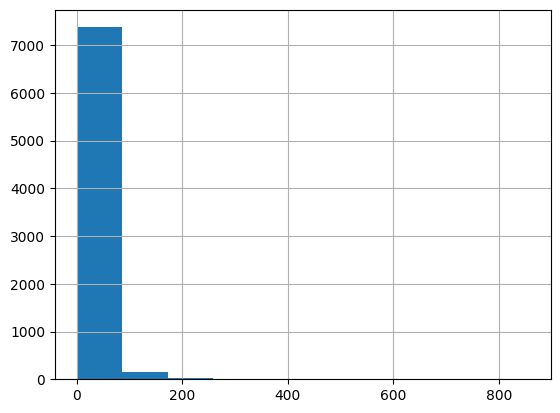

In [62]:
df['releases_total'].hist()